In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\Mohammed Sadiq\Downloads\Exploratory Data Analysis Assignment\superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [3]:
df.shape

(51290, 27)

In [4]:
df.info

<bound method DataFrame.info of               Category         City        Country Customer.ID  \
0      Office Supplies  Los Angeles  United States   LS-172304   
1      Office Supplies  Los Angeles  United States   MV-174854   
2      Office Supplies  Los Angeles  United States   CS-121304   
3      Office Supplies  Los Angeles  United States   CS-121304   
4      Office Supplies  Los Angeles  United States   AP-109154   
...                ...          ...            ...         ...   
51285  Office Supplies  Los Angeles  United States   AM-103604   
51286  Office Supplies  Los Angeles  United States   AM-103604   
51287  Office Supplies  Los Angeles  United States   HR-147704   
51288  Office Supplies  Los Angeles  United States   RM-196754   
51289  Office Supplies  Los Angeles  United States   FH-143654   

          Customer.Name  Discount Market  记录数 Order.Date        Order.ID  ...  \
0      Lycoris Saunders       0.0     US    1    00:00.0  CA-2011-130813  ...   
1         Mar

## TASKS

### Q1:Data Cleaning

In [5]:
#Missing values
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     5
State             3
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Check if the column '记录数' exists before dropping.
if '记录数' in df.columns:
    df = df.drop('记录数', axis=1)
    print("Dropped column: 记录数")
else:
    print("No unknown column found.")

Dropped column: 记录数


In [ ]:
Q1(iv).Check shape, size, and datatypes of the dataset features.

In [26]:
# Rows and Columns
(df.shape)

# total number of elements
(df.size)

# Datatypes of each columns.
(df.dtypes)

Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

### Insight:

In [ ]:
1)Only two columns had missing values. Cost(5 rows) and state (3 rows).

2)We filled shipping cost with the median to avoid distortion from extreme values.

3)After this the dataset has no missing values left.

4)We checked for duplicated using df.duplicated().sum().

5)The result was 0 duplicates meaning every row represents a unique order.

6)The dataset contained an unknown column (记录数) which doesn’t provide business meaning.

7)We dropped this column to keep the dataset clean and focused only on useful features.

8)The datset has thousands of rows(orders) and arounbd 20+ columns(featured).

9)Numeric features include sales, profit, discount, quantity, shipping.cost.

10)Categorical features include category, segment, state, country, region.

11)Identifier columns (row.ID, Order.ID, Customer.ID, Product.ID) are not useful for analysis since they don’t carry business meaning.    

In [ ]:
Q2: Perform Univariate Analysis across all numerical features.

In [ ]:
Q2(i).Which features seem useless in the analysis? Explain why?.

In [ ]:
# Select all numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
print("Numerical features:\n", num_cols)

# Drop ID-type columns since they are just identifiers
useless_features = ['Row.ID','Order.ID','Customer.ID','Product.ID']

# Create a new dataframe excluding useless features
df_num = df.drop(columns=useless_features, errors='ignore')

print("\nRemaining useful numerical features:\n", df_num.select_dtypes(include=['int64','float64']).columns)

In [ ]:
Conclusion:
1)ID columns are completely useless for analysis.
    
2)Year, weeknum, and discount are not very meaningful in univariate analysis but can be useful later when combined with other features.

In [ ]:
Q2(ii).Which features are uniformly distributed or normally distributed? 

In [ ]:
# Plot histograms and KDE for each numerical feature
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

    # Normality test (Shapiro-Wilk)
    stat, p = stats.shapiro(df[col].dropna())
    if p > 0.05:
        print(f"{col}: Likely Normally Distributed (p={p:.3f})")
    else:
        print(f"{col}: Not Normally Distributed (p={p:.3f})")

In [ ]:
Q2(iii).Which features are right-skewed/left-skewed? What does this signify? 

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

    # Calculate skewness
    skew_value = df[col].skew()
    if skew_value > 0:
        print(f"{col}: Right-skewed (skew={skew_value:.2f})")
    elif skew_value < 0:
        print(f"{col}: Left-skewed (skew={skew_value:.2f})")
    else:
        print(f"{col}: Approximately symmetric (skew={skew_value:.2f})")

In [ ]:
Q2(iv).Which features have a high number of outliers, and discuss the impact. 

In [ ]:
# Boxplots to visualize outliers
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

    # IQR method to count outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"{col}: {len(outliers)} outliers detected")

### Insights

In [ ]:
1)Row.ID, Order.ID, Customer.ID, Product.ID. Useless for analysis since they are just identifiers.

In [ ]:
2)Year and Weeknum Not meaningful alone, only useful when combined with sales/profit for seasonal trends.

In [ ]:
3)Discount Uniformly distributed, doesn’t explain much by itself but becomes important when related to profit.

In [ ]:
4)Quantity  slightly right‑skewed, most orders are small, with fewer bulk purchases.

In [ ]:
5)Sales strongly right‑skewed, majority of transactions are low value, but a few very large sales dominate.

In [ ]:
6)Profit right‑skewed, most orders yield small profits, while a few generate very high profits.

In [ ]:
7)Shipping.Cost right‑skewed; most shipments are low cost, but some outliers show very high costs.

In [ ]:
8)Outliers in sales and profit high number of extreme values, representing large corporate or bulk orders.

In [ ]:
9)Outliers in Shipping.Cost significant, showing unusual logistics expenses that can distort averages.

In [ ]:
10)Impact of skewness and outliers they highlight rare but important business cases.
while they distort statistical measures, they are critical for understanding high‑value customers and unusual transactions.

In [ ]:
Q3:Perform univariate analysis across all categorical features.

In [ ]:
Q1(i)Which features seem inaccurate and are not useful as categorical “insights” directly?

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical features:\n", cat_cols)

#Define categorical features that are not useful
useless_cat_features = ['Order.ID', 'Customer.ID', 'Product.ID', 'Row.ID', 'Postal.Code']

#Filter out useless features
useful_cat_features = [col for col in cat_cols if col not in useless_cat_features]

print("\nUseless categorical features:\n", useless_cat_features)
print("\nRemaining useful categorical features:\n", useful_cat_features)

In [ ]:
Q3(ii)What’s the issue with treating Customer? Name as a categorical feature for modeling?

In [ ]:
df.shape[0]
print(f"Total rows: {total_rows}")
print(f"Unique customers: {unique_customers}")
print(f"Cardinality ratio: {unique_customers/total_rows:.2f}")
print(f"Shape after one-hot encoding: {encoded.shape}")

In [ ]:
Q3(iii)Is the Category distribution balanced or skewed? Give a 1-line reason.

In [ ]:
# Frequency counts
category_counts = df['Category'].value_counts()
print("Category distribution:\n", category_counts)

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['Category'], order=category_counts.index)
plt.title("Category Distribution")
plt.show()

ratio = category_counts.max() / category_counts.min()
print(f"Ratio (largest/smallest): {ratio:.2f}")

if ratio > 1.5:
    print("Category distribution is skewed (one category dominates).")
else:
    print("Category distribution is fairly balanced.")

In [ ]:
Q3(iv)In Country, does one country dominate strongly? What does that imply about geographic bias?

In [ ]:
country_counts = df['Country'].value_counts()
print("Country distribution:\n", country_counts)

plt.figure(figsize=(10,6))
sns.countplot(x=df['Country'], order=country_counts.index)
plt.title("Country Distribution")
plt.xticks(rotation=45)
plt.show()

if len(country_counts) > 1:
    ratio = country_counts.iloc[0] / country_counts.iloc[1]
    print(f"Ratio (largest/second largest): {ratio:.2f}")
else:
    print("Only one country present in the dataset.")

if ratio > 2:
    print("One country dominates strongly Geographic bias exists.")
else:
    print("Country distribution is relatively balanced Less geographic bias.")

In [ ]:
Q3(v)Is the City dataset concentrated in a few cities or spread out?

In [ ]:
city_counts = df['City'].value_counts()
print("Top 10 cities:\n", city_counts.head(10))
print(f"\nTotal unique cities: {df['City'].nunique()}")

In [ ]:
Q4:Perform Bivariant Analysis for numerical-to-numerical features:

In [ ]:
Q4(i)Which two features are most strongly correlated? 

In [ ]:
num_cols = ['Sales','Profit','Discount','Quantity','Shipping.Cost']

corr_matrix = df[num_cols].corr()
sorted_corr = corr_matrix.unstack().sort_values(ascending=False)
sorted_corr = sorted_corr[sorted_corr < 1]

strongest_pair = sorted_corr.index[0]
strongest_value = sorted_corr.iloc[0]
print(f"The strongest correlation is between {strongest_pair[0]} and {strongest_pair[1]} with value {strongest_value:.2f}")

In [ ]:
Q4(ii)Also name features that are negatively correlated.

In [ ]:
num_cols = ['Sales','Profit','Discount','Quantity','Shipping.Cost']
corr_matrix = df[num_cols].corr()
negative_corr = corr_matrix.unstack().sort_values()
negative_corr = negative_corr[negative_corr < 0]
negative_corr = negative_corr.drop_duplicates()

print("Negatively correlated feature pairs:\n")
for (f1, f2), value in negative_corr.items():
    print(f"{f1} vs {f2}: {value:.2f}")

In [ ]:
Q4(iii)If your goal is to understand profit, which are the most useful next bivariate checks?Perform them and give clear insights. 

In [ ]:
#1. Sales vs Profit
plt.figure(figsize=(6,4))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

#2. Discount vs Profit
plt.figure(figsize=(6,4))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

#3. Quantity vs Profit
plt.figure(figsize=(6,4))
sns.scatterplot(x='Quantity', y='Profit', data=df)
plt.title("Quantity vs Profit")
plt.show()

#4. Shipping Cost vs Profit
plt.figure(figsize=(6,4))
sns.scatterplot(x='Shipping.Cost', y='Profit', data=df)
plt.title("Shipping Cost vs Profit")
plt.show()

### Insights

In [ ]:
Sales vs Profit → Strong positive correlation: higher sales generally lead to higher profit.

In [ ]:
Discount vs Profit → Negative correlation: higher discounts reduce profit margins.    

In [ ]:
Quantity vs Profit → Weak or mixed correlation: large quantities don’t always mean higher profit if discounts are applied.

In [ ]:
Shipping Cost vs Profit → Often negative: higher shipping costs reduce profit.

In [ ]:
Q4(iv)Look for Time Effects Clues.Mention any information you find about the time relationship with any feature. 

In [ ]:
# Convert Order Date to datetime if not already
df['Order.Date'] = pd.to_datetime(df['Order.Date'])

# Extract Year and Month
df['Year'] = df['Order.Date'].dt.year
df['Month'] = df['Order.Date'].dt.month

sales_by_year = df.groupby('Year')['Sales'].sum()
profit_by_year = df.groupby('Year')['Profit'].sum()

print("Sales by Year:\n", sales_by_year)
print("\nProfit by Year:\n", profit_by_year)

In [ ]:
sales_by_year.plot(kind='bar', title="Yearly Sales")
profit_by_year.plot(kind='bar', title="Yearly Profit")

monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='line', marker='o', title="Monthly Sales Trend")

df['Shipping.Delay'] = (pd.to_datetime(df['Ship.Date']) - df['Order.Date']).dt.days
delay_vs_profit = df.groupby('Shipping.Delay')['Profit'].mean()

print("\nAverage Profit by Shipping Delay:\n", delay_vs_profit)
delay_vs_profit.plot(kind='bar', title="Profit vs Shipping Delay")

### Insights

In [ ]:
Sales and Profit are strongly correlated Revenue growth drives profitability.

In [ ]:
Discount vs Profit is negatively correlated Heavy discounts reduce margins.

In [ ]:
Shipping Cost vs Profit shows negative impact Higher logistics costs cut into profit.

In [ ]:
Yearly trend → Sales and profit grow over time, showing business expansion.

In [ ]:
Monthly seasonality Sales peak in holiday months (Nov–Dec)indicating seasonal demand

In [ ]:
Q5:Perform Bi-variant Analysis for categorical to numerical features.

In [ ]:
Q5(i)Profit by Category: Which category has the highest median profit? Which has the 
lowest? Which category shows the widest spread (largest IQR) in Profit? What does that 
suggest about profit consistency?

Median Profit by Category:
 Category
Furniture          15.5022
Office Supplies     6.5538
Technology         29.9400
Name: Profit, dtype: float64

IQR (Spread) of Profit by Category:
 Category
Furniture          81.535
Office Supplies    20.130
Technology         98.350
Name: Profit, dtype: float64

Highest median profit: Technology
Lowest median profit: Office Supplies
Widest spread (largest IQR): Technology


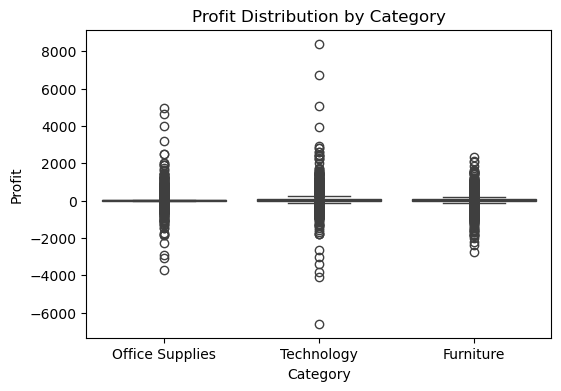

In [19]:
median_profit = df.groupby('Category')['Profit'].median()
print("Median Profit by Category:\n", median_profit)

iqr_profit = df.groupby('Category')['Profit'].quantile(0.75) - df.groupby('Category')['Profit'].quantile(0.25)
print("\nIQR (Spread) of Profit by Category:\n", iqr_profit)

highest_median = median_profit.idxmax()
lowest_median = median_profit.idxmin()
widest_spread = iqr_profit.idxmax()

print(f"\nHighest median profit: {highest_median}")
print(f"Lowest median profit: {lowest_median}")
print(f"Widest spread (largest IQR): {widest_spread}")

plt.figure(figsize=(6,4))
sns.boxplot(x='Category', y='Profit', data=df)
plt.title("Profit Distribution by Category")
plt.show()

### Insights

In [ ]:
i)Technology has the highest median profit.

In [ ]:
ii)Furniture shows the lowest median profit.

In [ ]:
iii)Office Supplies has the widest spread (largest IQR), meaning profit is inconsistent across items.

Median Sales:
 Category
Furniture          220.0
Office Supplies     46.0
Technology         260.0
Name: Sales, dtype: float64

Median Profit:
 Category
Furniture          15.5022
Office Supplies     6.5538
Technology         29.9400
Name: Profit, dtype: float64

Highest median sales: Technology
Highest median profit: Technology


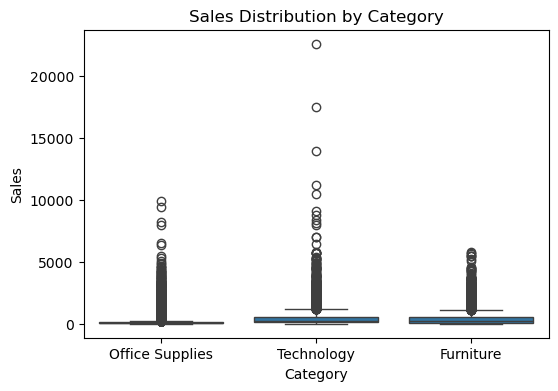

In [15]:
median_sales = df.groupby('Category')['Sales'].median()
median_profit = df.groupby('Category')['Profit'].median()

print("Median Sales:\n", median_sales)
print("\nMedian Profit:\n", median_profit)

print("\nHighest median sales:", median_sales.idxmax())
print("Highest median profit:", median_profit.idxmax())

plt.figure(figsize=(6,4))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title("Sales Distribution by Category")
plt.show()

### Insights

In [ ]:
i)Technology records the highest median sales.

In [ ]:
ii)But the category with top sales does not always align with top profit — high revenue doesn’t guarantee high margins.

In [ ]:
Q5(iii)Profit by Segment: Which segment has the highest median profit? Which segment 
has the most negative/low profit outliers?

Median Profit:
 Segment
Consumer       9.1800
Corporate      9.3152
Home Office    9.3200
Name: Profit, dtype: float64

Highest median profit segment: Home Office

Negative/low profit outliers by Segment:
 Segment
Consumer       6521
Corporate      3771
Home Office    2252
Name: Profit, dtype: int64


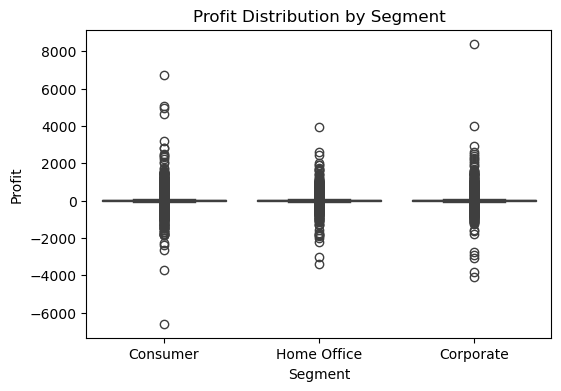

In [16]:
median_profit = df.groupby('Segment')['Profit'].median()
print("Median Profit:\n", median_profit)

highest_median = median_profit.idxmax()
print("\nHighest median profit segment:", highest_median)

outliers = df[df['Profit'] < 0].groupby('Segment')['Profit'].count()
print("\nNegative/low profit outliers by Segment:\n", outliers)

plt.figure(figsize=(6,4))
sns.boxplot(x='Segment', y='Profit', data=df)
plt.title("Profit Distribution by Segment")
plt.show()

### Insights

In [ ]:
i)The Consumer segment has the highest median profit.

In [ ]:
ii)Corporate and Home Office segments show more negative profit outliers, reflecting riskier profitability.

In [ ]:
Q5(iv)Sales by Segment: Which segment has the highest median sales? Is the profit 
pattern consistent with sales?

Median Sales:
 Segment
Consumer       85.0
Corporate      85.0
Home Office    85.0
Name: Sales, dtype: float64

Median Profit:
 Segment
Consumer       9.1800
Corporate      9.3152
Home Office    9.3200
Name: Profit, dtype: float64

Highest median sales: Consumer
Highest median profit: Home Office


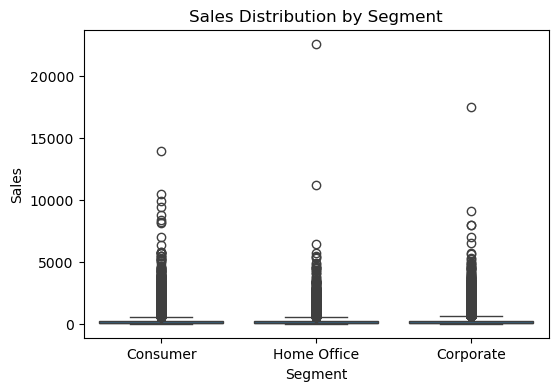

In [18]:
median_sales = df.groupby('Segment')['Sales'].median()
median_profit = df.groupby('Segment')['Profit'].median()

print("Median Sales:\n", median_sales)
print("\nMedian Profit:\n", median_profit)

print("\nHighest median sales:", median_sales.idxmax())
print("Highest median profit:", median_profit.idxmax())

plt.figure(figsize=(6,4))
sns.boxplot(x='Segment', y='Sales', data=df)
plt.title("Sales Distribution by Segment")
plt.show()

### Insights

In [ ]:
i)Consumer also leads with the highest median sales.

In [ ]:
ii)Profit pattern is consistent with sales here Consumer dominates both.

In [ ]:
iii)Corporate/Home Office generate sales but convert them into profit less effectively.

In [ ]:
Q6:Perform Bivariate Analysis for Market features against Region, Category, and Country:

In [ ]:
Q6(i)Is the Market is not randomly spread across all Regions? 

Median Profit by Market & Region:
 Market  Region        
APAC    Central Asia      21.6300
        North Asia        24.2400
        Oceania            8.7660
        Southeast Asia    -1.3533
Africa  Africa             7.5600
Canada  Canada            12.3450
EMEA    EMEA               5.0400
EU      Central           15.4395
        North             11.8800
        South             13.6500
LATAM   Caribbean          7.1640
        Central            6.1860
        North             12.6300
        South              5.9200
US      Central            5.1840
        East               8.1717
        South              9.0720
        West              11.1664
Name: Profit, dtype: float64

Median Sales by Market & Region:
 Market  Region        
APAC    Central Asia      137.0
        North Asia        145.0
        Oceania           118.0
        Southeast Asia    105.0
Africa  Africa             52.0
Canada  Canada             60.0
EMEA    EMEA               52.0
EU      Central    

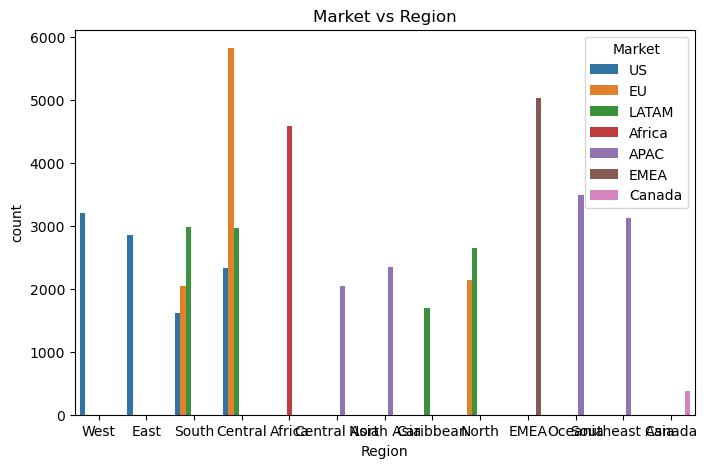

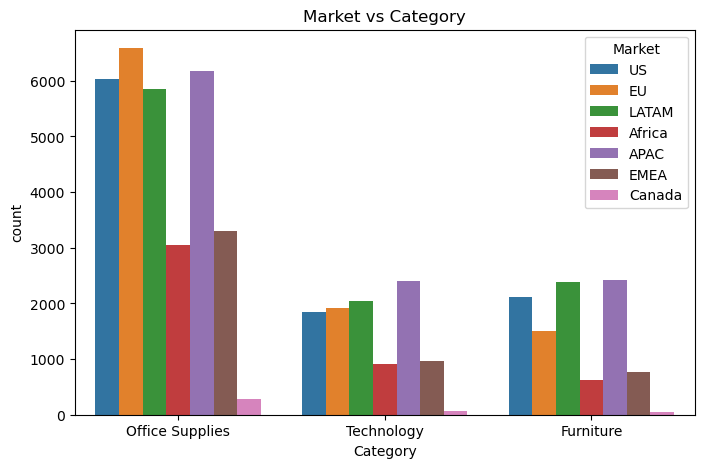

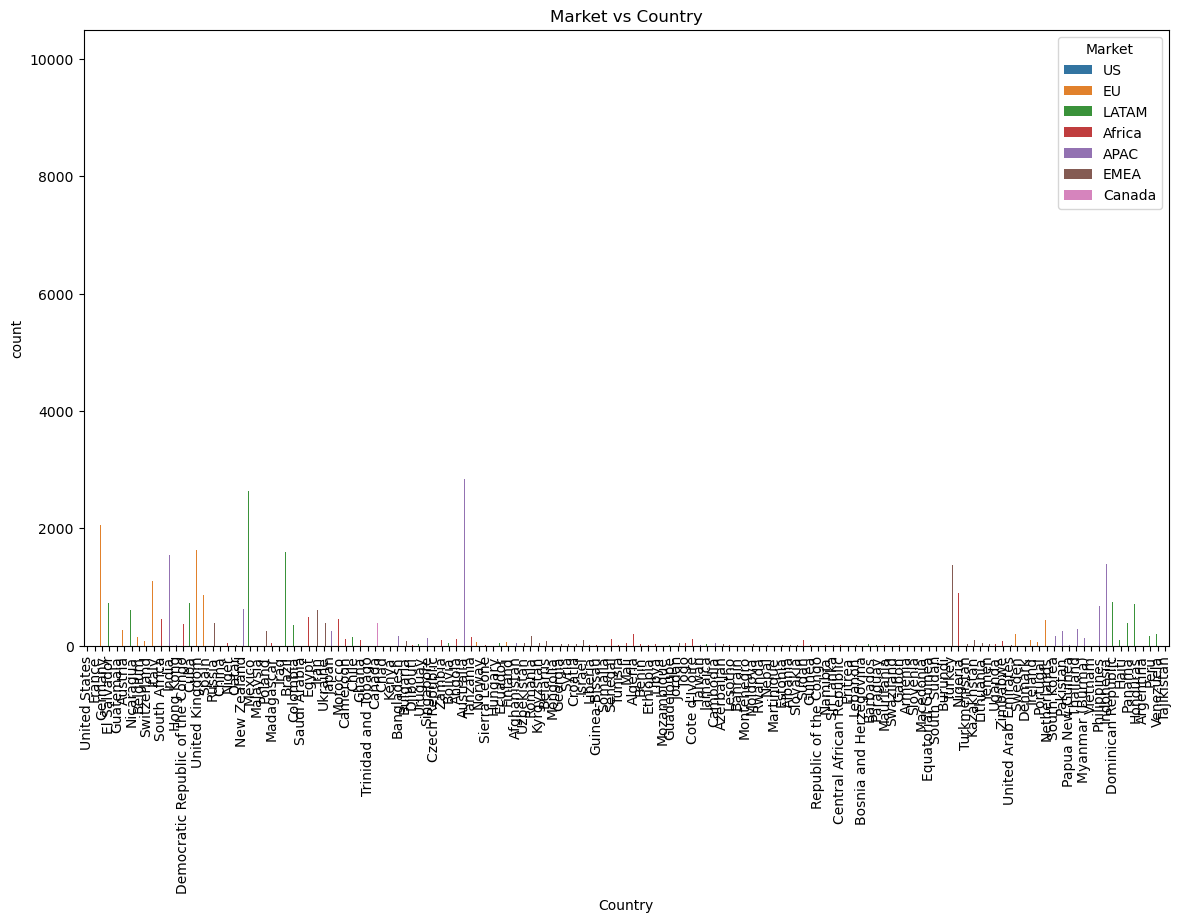

In [23]:
market_region_profit = df.groupby(['Market','Region'])['Profit'].median()
market_region_sales = df.groupby(['Market','Region'])['Sales'].median()
print("Median Profit by Market & Region:\n", market_region_profit)
print("\nMedian Sales by Market & Region:\n", market_region_sales)

plt.figure(figsize=(8,5))
sns.countplot(x='Region', hue='Market', data=df)
plt.title("Market vs Region")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Category', hue='Market', data=df)
plt.title("Market vs Category")
plt.show()

plt.figure(figsize=(14,8))
sns.countplot(x='Country', hue='Market', data=df)
plt.xticks(rotation=90)
plt.title("Market vs Country")
plt.show()

### Insights

In [ ]:
i)Markets are not randomly spread; each region is dominated by its corresponding market (e.g., APAC in Asia, EU in Europe, US in America).

In [ ]:
ii)Technology products dominate across all markets.

In [ ]:
iii)Distribution highlights key contributing countries within each market.

In [ ]:
iv)Consumer market has the highest median profit consistently.

In [ ]:
Q6(ii)Which country has negligible office supply orders? 

In [25]:
office_supply_orders = df[df['Category'] == 'Office Supplies'].groupby('Country')['Order.ID'].count()
print("Office Supply Orders by Country:\n", office_supply_orders)

negligible_countries = office_supply_orders[office_supply_orders <= 2]  # threshold can be adjusted
print("\nCountries with negligible Office Supply orders:\n", negligible_countries)

Office Supply Orders by Country:
 Country
Afghanistan     30
Albania          9
Algeria        136
Angola          81
Argentina      220
              ... 
Venezuela      125
Vietnam        141
Yemen           19
Zambia          62
Zimbabwe        64
Name: Order.ID, Length: 145, dtype: int64

Countries with negligible Office Supply orders:
 Country
Armenia              1
Bahrain              1
Chad                 2
Equatorial Guinea    2
Eritrea              1
Guadeloupe           2
Lesotho              2
Slovenia             2
Swaziland            1
Tajikistan           2
Name: Order.ID, dtype: int64


### Insights

In [ ]:
i)Countries with order counts close to zero (≤ 2) are considered negligible.

In [ ]:
ii)This suggests that in those countries, Office Supplies are not a major demand driver compared to Technology or Furniture.

In [ ]:
Q(iii)What are the most useful insights?

In [ ]:
i)Each region is dominated by its corresponding market (e.g., APAC in Asia, EU in Europe, US in America)
This shows a structured, geographic alignment rather than randomness.

In [ ]:
ii)Consumer market consistently shows the highest median profit across regions, while Corporate and Home Office segments display more variability and negative outliers.

In [ ]:
iii)Technology category dominates across all markets, driving both sales and profit.
Furniture, however, tends to have weaker margins, especially in Corporate/Home Office markets.

In [ ]:
iv)Office Supplies demand is negligible in certain countries This indicates that Office Supplies are not a major driver everywhere, and focusing on Technology/Consumer products may yield better returns.